# Model Diagnostics - fair results & comparison

Covers four lenses on the forecasting system:

- **B** Point comparison: Naive / Lasso / LightGBM / ARIMAX
- **C** Quantile calibration: LightGBM vs. ARIMAX
- **D** ARIMAX coefficients by regime (economic reading)
- **E** Forecast vs. Actual + Fan Chart (two windows)
- **F** SHAP interpretation + Lasso comparison
- **G** Feature ablation (D6 weak candidates)
- **H** Summary and hand-off to Sprint 4


## A. Setup & Constants

In [16]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from energy_price_forecast.data.loaders import load_interim_hourly, load_processed_features
from energy_price_forecast.evaluation.metrics import summarise, summarise_quantiles
from energy_price_forecast.models.arimax import ARIMAXForecaster, select_arimax_exog
from energy_price_forecast.models.baseline import LassoForecaster
from energy_price_forecast.models.lgbm import LGBMForecaster

warnings.filterwarnings("ignore")

# Resolve project root: walk up from cwd, then check one level down as fallback
# (handles the case where a previous os.chdir moved cwd above the project root)
def _find_root(marker: str = "pyproject.toml") -> Path:
    cwd = Path.cwd()
    found = next((p for p in [cwd, *cwd.parents] if (p / marker).exists()), None)
    if found is None:
        found = next((c for c in cwd.iterdir() if c.is_dir() and (c / marker).exists()), None)
    if found is None:
        raise RuntimeError(f"Cannot locate project root ({marker} not found) from {cwd}")
    return found

os.chdir(_find_root())

# ── Prediction parquets ──────────────────────────────────────────────────────
DATA = Path("data/processed")

NAIVE_PARQUET   = DATA / "backtest_similarday.parquet"
LASSO_PARQUET   = DATA / "backtest_lasso.parquet"

# LightGBM — rolling-90, refit_every=1 (canonical benchmark, MAE ≈ 15.4)
LGBM_Q50_PARQUET = DATA / "preds_lgbm_q50_rolling90_refit1.parquet"
LGBM_Q05_PARQUET = DATA / "preds_lgbm_q05_rolling90.parquet"
LGBM_Q95_PARQUET = DATA / "preds_lgbm_q95_rolling90.parquet"

# LightGBM calibration CSV (expanding window, from step 3.3)
LGBM_CAL_CSV  = DATA / "lgbm_quantile_calibration.csv"

# ARIMAX v2 (rolling-90, refit_every=7, from step 3.4)
ARIMAX_Q05_PARQUET = DATA / "preds_arimax_v2_q05.parquet"
ARIMAX_Q50_PARQUET = DATA / "preds_arimax_v2_q50.parquet"
ARIMAX_Q95_PARQUET = DATA / "preds_arimax_v2_q95.parquet"
ARIMAX_CAL_CSV     = DATA / "arimax_v2_quantile_calibration.csv"

# Ablation parquet — produced by the Owner (see Panel G for command)
ABLATION_PARQUET = DATA / "preds_lgbm_q50_ablation.parquet"

# ── Walk-forward split point ─────────────────────────────────────────────────
TEST_START = "2021-01-01"

# ── Fan-chart windows (Owner: set to representative weeks) ───────────────────
# Calm week (normal regime, shows a tight band)
FAN_CALM_START = "2021-02-01"
FAN_CALM_END   = "2021-02-07"
# Crisis/spike week (shows tail behaviour and the narrow ARIMAX band)
FAN_CRISIS_START = "2022-08-22"
FAN_CRISIS_END   = "2022-08-28"

# ── ARIMAX regime windows (Owner: adjust if needed) ──────────────────────────
# One representative 90-day window per regime for the coefficient panel.
REGIME_WINDOWS = {
    "normal":      ("2020-04-01", "2020-07-01"),
    "crisis":      ("2021-10-01", "2022-01-01"),
    "post_crisis": ("2023-05-01", "2023-08-01"),
}

# ── D6 ablation feature names (verified against features/lags.py) ────────────
D6_WEAK_FEATURES = [
    "wind_offshore_forecast_error_lag_48h",
    "solar_forecast_error_lag_48h",
    "cross_border_deviation_lag_48h",
]

### LightGBM tuning Results

Before settling on the LightGBM defaults, hyperparameter tuning was run
in sprint 3.2 (Optuna over a leakage-safe inner walk-forward). It produced
**no material gain**: tuned MAE ≈ 17,78 vs. untuned ≈ 17,66
EUR/MWh on an expanding window, a difference within walk-forward variance rather than a stable
improvement. The model is therefore shipped **untuned**, which also means the
SHAP analysis below explains exactly the production model — no tuned split
structure sits between interpretation and delivery.

## B. Extended Point Comparison

All four models on a common test index. MAE/RMSE/WAPE via the same `summarise` function.

> **Footnote:** Lasso uses an expanding window; LightGBM uses rolling-90 with refit_every=1; ARIMAX uses rolling-90 with refit_every=7, but uses the Kalman-update in between. Furthermore, for ARIMAX, the feature set was slightly shrinked leaving out only unimportant features. The main reson is calculation cost.
> 

In [17]:
price = load_interim_hourly()["day_ahead_price"]

def _load_preds(path: Path) -> pd.DataFrame:
    return pd.read_parquet(path)

naive  = _load_preds(NAIVE_PARQUET)
lasso  = _load_preds(LASSO_PARQUET)
lgbm50 = _load_preds(LGBM_Q50_PARQUET)
arx50  = _load_preds(ARIMAX_Q50_PARQUET)

# Align on the intersection of all test indices
common_idx = naive.index.intersection(lasso.index).intersection(
    lgbm50.index).intersection(arx50.index)
y_common = price.reindex(common_idx)

rows = []
for name, df in [("Naive", naive), ("Lasso", lasso),
                 ("ARIMAX rolling-90", arx50),("LightGBM rolling-90", lgbm50)]:
    m = summarise(df.loc[common_idx])
    rows.append({"Model": name, **m})

pt = pd.DataFrame(rows).set_index("Model")
pt.style.format("{:.2f}")

,mae,rmse,wape,mae_per_day_mean,mae_per_day_std,mae_per_day_p05,mae_per_day_p50,mae_per_day_p95
Model,,,,,,,,
Naive,34.77,56.20,0.29,34.76,35.28,5.63,23.40,100.61
Lasso,24.23,38.40,0.20,24.23,22.91,5.57,17.43,66.00
ARIMAX rolling-90,22.87,35.74,0.19,22.86,18.64,5.50,18.07,55.48
LightGBM rolling-90,15.40,26.59,0.13,15.39,14.55,3.85,11.18,41.33


LigthGBM outperforms the other models significantly. ARIMAX is the second-best model, as expected.

## C. Quantile Calibration: LightGBM vs. ARIMAX

The ARIMAX quantiles are produced through the emprical residuals in the test window.



In [18]:
lgbm_cal  = pd.read_csv(LGBM_CAL_CSV, index_col=0)
arimax_cal = pd.read_csv(ARIMAX_CAL_CSV, index_col=0)

cal = pd.concat(
    {"LightGBM (rolling-90)": lgbm_cal, "ARIMAX (rolling-90)": arimax_cal},
    axis=1,
)
cal

LightGBM (rolling-90)           ARIMAX (rolling-90)          
                    pinball  coverage             pinball  coverage
alpha                                                              
0.05               2.850476  0.173348            3.715949  0.120154
0.50               7.699389  0.492352           11.433161  0.320647
0.95               3.572399  0.811036            8.465330  0.623442

LightGBM has the better fit but both models have problems with the long tailed distribution. Additionally, ARIMAX has es significant bias, which is most likely duo to the unfulfilled model assumptions: heteroskedacity in the test window and gaussiasn residuals. The ARIMAX quantiles can be explainde through construction: The empirical offsets are built from *one-step Kalman innovations*, not the actual
24h day-ahead forecast errors. For an AR process with φ₁ ≈ 1 the h-step variance grows ~h×,
so the band is roughly 4–5× too narrow. However, this is a fair comparison as both model quantiles can now be calibrated with empirical oos-forecast errors.

## D. ARIMAX Coefficients by Regime

Each column is a separate ARIMAX fit on a representative 90-day window from that regime.
Exog are z-scored at fit, so coefficients are in **EUR/MWh per 1 standard deviation** of the
regressor — magnitudes are directly comparable across regressors.

**Economic glossary:**
- `residual_load_forecast` → **merit-order slope** (higher residual load → more expensive marginal plant → higher price)
- `ttf_gas_lag_48h` → **gas pass-through** (gas shifts the merit-order curve vertically; hypothesis: larger during the 2021–2023 energy crisis)
- `eua_co2_lag_48h` → **CO₂ cost pass-through**
- `is_weekend` / `is_holiday` / `is_regional_holiday` → demand-side level shifts (less load → lower price)
- `eua_missing`, `is_crisis`, `is_post_crisis` → structural indicators; note these are constant within their
  own regime window and are therefore dropped by the zero-variance filter — their absence here is expected.

> **Footnote:** one window per regime is one fit. Treat the coefficient panel as
> illustrative, not as a statistically robust estimate.

In [19]:
features_full = load_processed_features()
price_full = load_interim_hourly()["day_ahead_price"]
x_full = select_arimax_exog(features_full)
y_full = price_full.reindex(features_full.index)

coef_rows: dict[str, pd.Series] = {}
for regime, (start, end) in REGIME_WINDOWS.items():
    mask = (features_full.index >= start) & (features_full.index < end)
    x_win = x_full.loc[mask]
    y_win = y_full.loc[mask]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m = ARIMAXForecaster()
        m.fit(y_win, x_win)
    coef_rows[regime] = m.exog_coefficients

coef_df = pd.DataFrame(coef_rows)
coef_df.style.format("{:.3f}").background_gradient(axis=None, cmap="RdBu_r", vmin=-10, vmax=10)

,normal,crisis,post_crisis
eua_co2_lag_48h,0.000,7.593,2.091
eua_missing,nan,2.807,0.975
is_holiday,0.728,-9.839,0.628
is_regional_holiday,0.074,-4.829,0.456
is_weekend,0.346,7.957,1.458
residual_load_forecast,11.083,68.943,32.263
ttf_gas_lag_48h,-0.351,12.010,1.772


The magnitude of the coefficients reflects the price levels. Clearly, the gas coefficient spikes during the crisis as expected.

## E. Forecast vs. Actual + Fan Chart

Two representative weeks: a calm period (normal regime) and a crisis/spike week.
LightGBM q05–q95 band shown; ARIMAX overlay shows the too-narrow band.

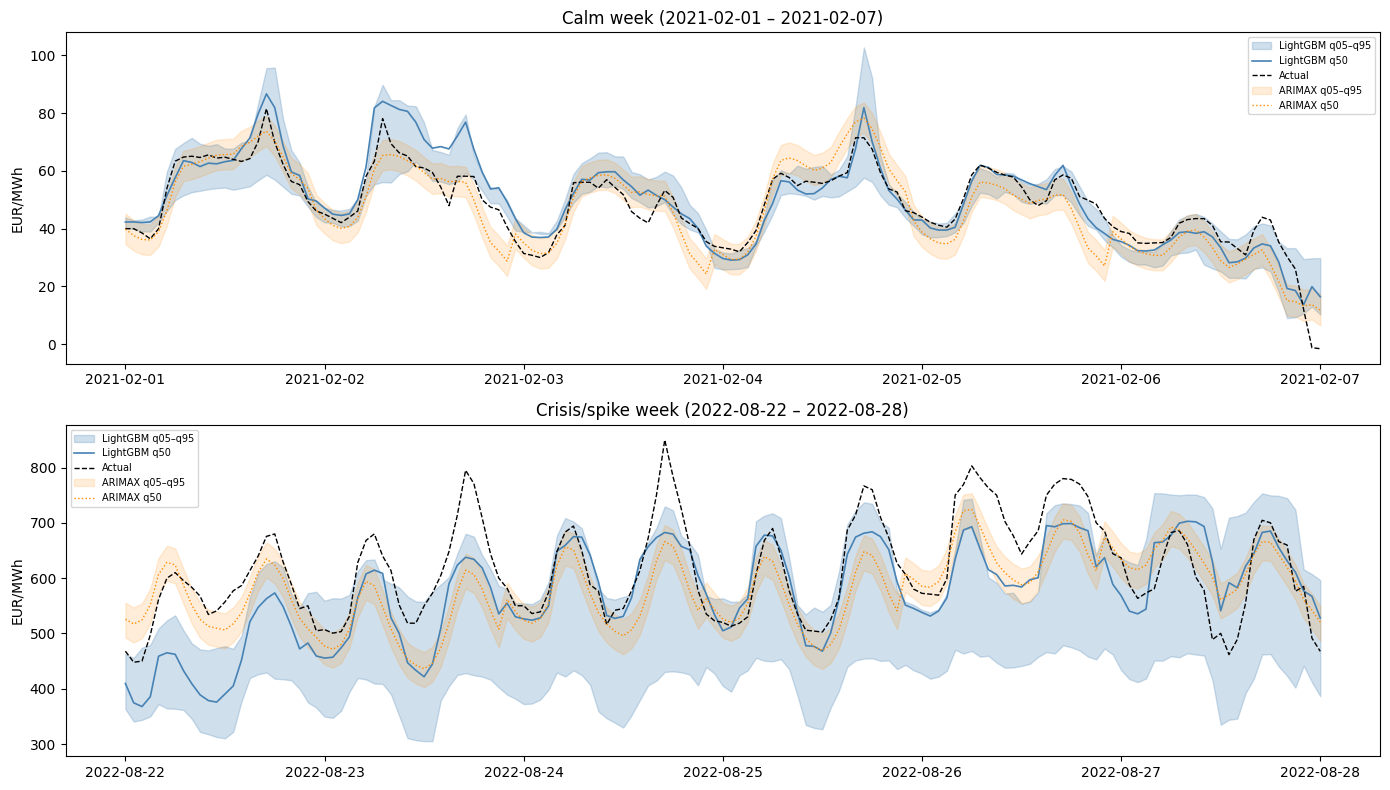

In [20]:
lgbm05 = _load_preds(LGBM_Q05_PARQUET)
lgbm95 = _load_preds(LGBM_Q95_PARQUET)
arx05  = _load_preds(ARIMAX_Q05_PARQUET)
arx95  = _load_preds(ARIMAX_Q95_PARQUET)

def _fan_chart(ax: plt.Axes, window_start: str, window_end: str, title: str) -> None:
    mask = (price.index >= window_start) & (price.index <= window_end)
    idx = price.index[mask]
    # Only plot where all series have data
    idx = idx.intersection(lgbm50.index).intersection(lgbm05.index).intersection(lgbm95.index)
    y_act  = price.loc[idx]
    y_mid  = lgbm50.loc[idx, "y_pred"]
    y_lo   = lgbm05.loc[idx, "y_pred"]
    y_hi   = lgbm95.loc[idx, "y_pred"]

    ax.fill_between(idx, y_lo, y_hi, alpha=0.25, label="LightGBM q05–q95", color="steelblue")
    ax.plot(idx, y_mid, color="steelblue", lw=1.2, label="LightGBM q50")
    ax.plot(idx, y_act, color="black", lw=1.0, linestyle="--", label="Actual")

    # ARIMAX overlay — only where data exists
    arx_idx = idx.intersection(arx50.index).intersection(arx05.index).intersection(arx95.index)
    if len(arx_idx):
        ax.fill_between(arx_idx,
                        arx05.loc[arx_idx, "y_pred"], arx95.loc[arx_idx, "y_pred"],
                        alpha=0.15, color="darkorange", label="ARIMAX q05–q95")
        ax.plot(arx_idx, arx50.loc[arx_idx, "y_pred"],
                color="darkorange", lw=1.0, linestyle=":", label="ARIMAX q50")

    ax.set_title(title)
    ax.set_ylabel("EUR/MWh")
    ax.legend(fontsize=7)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
_fan_chart(axes[0], FAN_CALM_START,   FAN_CALM_END,   f"Calm week ({FAN_CALM_START} – {FAN_CALM_END})")
_fan_chart(axes[1], FAN_CRISIS_START, FAN_CRISIS_END, f"Crisis/spike week ({FAN_CRISIS_START} – {FAN_CRISIS_END})")
fig.tight_layout()
plt.show()

## F. SHAP Interpretation

One `LGBMForecaster(alpha=0.5)` fit on all pre-test data (index < `TEST_START`).
SHAP explains exactly the delivered model — no separately refitted version.

The Lasso is refitted on the same pre-test window for comparison.
Its coefficient magnitudes (sorted) show what the linear model uses;
SHAP `mean(|SHAP|)` shows what the tree uses — including non-linearities and interactions.

In [21]:
features = load_processed_features()
price_feat = load_interim_hourly()["day_ahead_price"].reindex(features.index)

pre_mask = features.index < TEST_START
x_pre = features.loc[pre_mask]
y_pre = price_feat.loc[pre_mask]

# ── LightGBM fit ─────────────────────────────────────────────────────────────
lgbm_shap = LGBMForecaster(alpha=0.5)
lgbm_shap.fit(y_pre, x_pre)
est = lgbm_shap.fitted_estimator

explainer = shap.TreeExplainer(est)

# Compute SHAP on all pre-test data → stable mean(|SHAP|) ranking for bar chart
shap_values_full = explainer.shap_values(x_pre)
mean_abs_shap = pd.Series(
    np.abs(shap_values_full).mean(axis=0), index=x_pre.columns
).sort_values(ascending=False)

# Subsample for beeswarm rendering only (display, not ranking)
sample_idx = np.random.default_rng(0).choice(len(x_pre), size=min(5000, len(x_pre)), replace=False)
x_sample        = x_pre.iloc[sample_idx]
shap_values_sample = shap_values_full[sample_idx]

print(f"SHAP computed on {len(x_pre):,} pre-test observations; beeswarm subsampled to {len(x_sample):,}.")
print(f"\nTop-5 features by mean(|SHAP|):\n{mean_abs_shap.head()}")


SHAP computed on 8,593 pre-test observations; beeswarm subsampled to 5,000.

Top-5 features by mean(|SHAP|):
residual_load_forecast      7.139578
month_sin                   2.923963
price_lag_168h              2.232892
price_lag_24h               1.993473
renewable_share_forecast    0.843880
dtype: float64


In [22]:
# ── Lasso fit for comparison ──────────────────────────────────────────────────
lasso_model = LassoForecaster()
lasso_model.fit(y_pre, x_pre)
lasso_pipe  = lasso_model._pipeline  # sklearn Pipeline: simpleimputer → standardscaler → lassocv
lasso_coefs = pd.Series(
    np.abs(lasso_pipe.named_steps["lassocv"].coef_),
    index=x_pre.columns,
).sort_values(ascending=False)

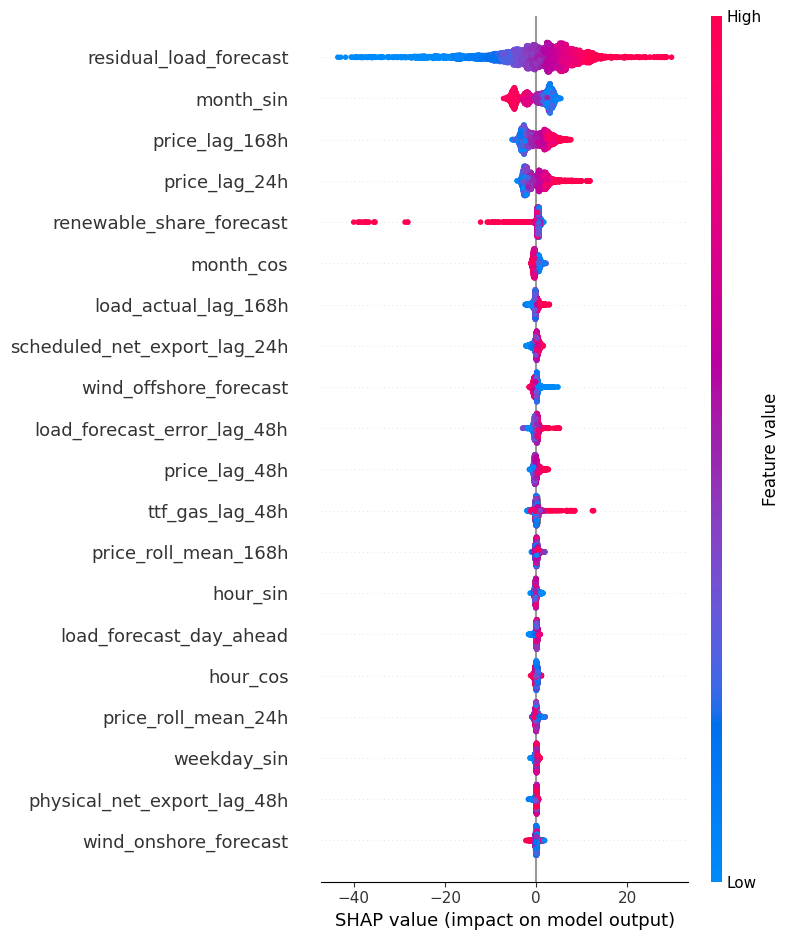

In [23]:
shap.summary_plot(
    shap_values_sample,
    x_sample,
    plot_type="dot",
    max_display=20,
    show=True,
)

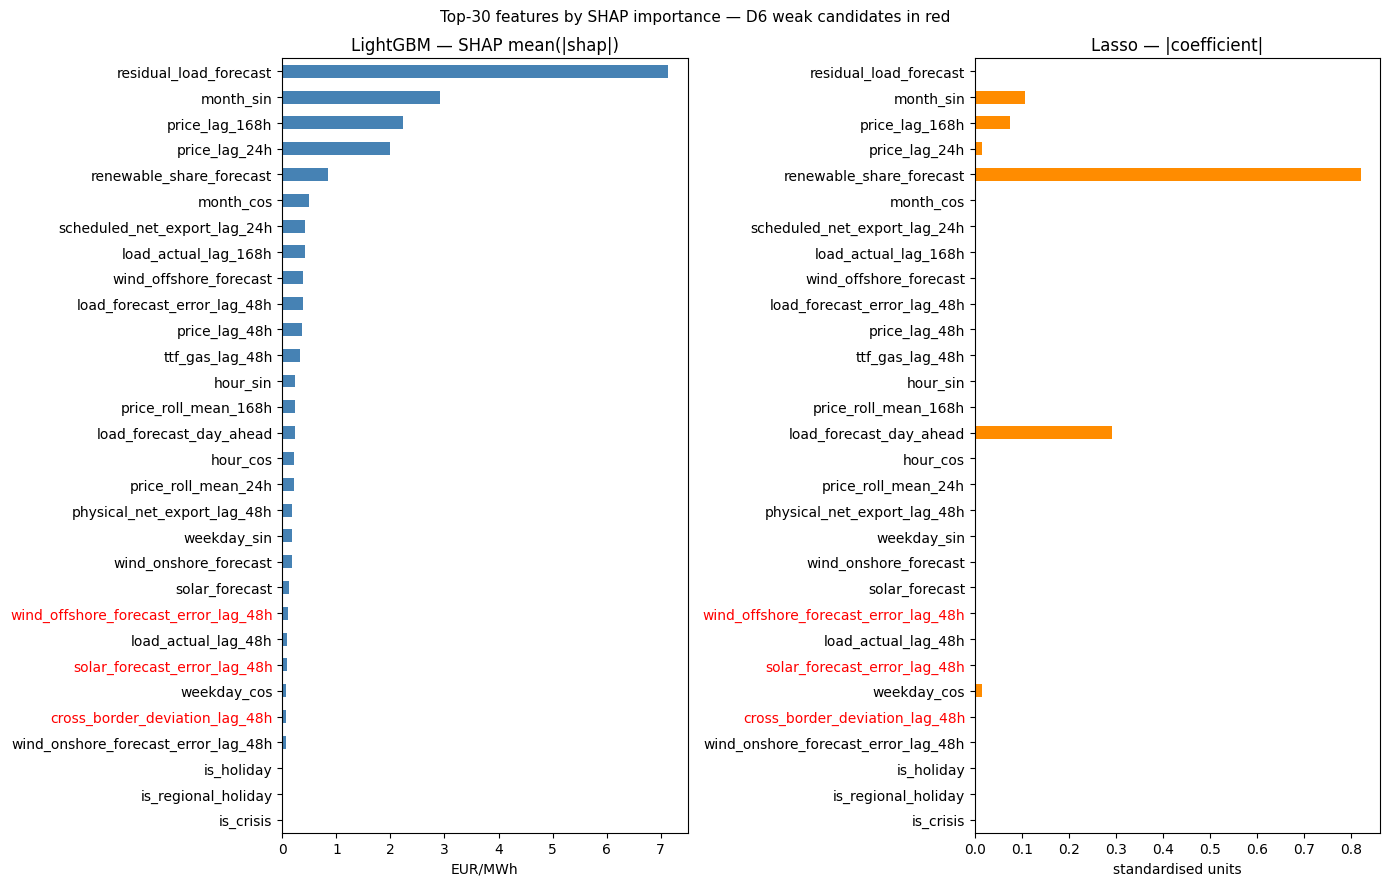


D6 candidates SHAP rank:
  wind_offshore_forecast_error_lag_48h: rank 22 / 34, mean|shap|=0.1015
  solar_forecast_error_lag_48h: rank 24 / 34, mean|shap|=0.0769
  cross_border_deviation_lag_48h: rank 26 / 34, mean|shap|=0.0645


In [24]:
# ── mean(|SHAP|) ranking vs. Lasso |coef| ranking ────────────────────────────
top_n = 30

# Build compare from the two independently-sorted Series.
# Re-sort explicitly before plotting so bar order is always correct
# regardless of how pandas aligns the two Series on construction.
shap_top   = mean_abs_shap.head(top_n).sort_values(ascending=True)
lasso_top  = lasso_coefs.reindex(shap_top.index)   # same features, Lasso values

fig, axes = plt.subplots(1, 2, figsize=(14, 9))

shap_top.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("LightGBM — SHAP mean(|shap|)")
axes[0].set_xlabel("EUR/MWh")

lasso_top.plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("Lasso — |coefficient|")
axes[1].set_xlabel("standardised units")

# Mark D6 weak candidates
for ax in axes:
    for label in ax.get_yticklabels():
        if label.get_text() in D6_WEAK_FEATURES:
            label.set_color("red")

fig.suptitle(f"Top-{top_n} features by SHAP importance — D6 weak candidates in red", fontsize=11)
fig.tight_layout()
plt.show()

print("\nD6 candidates SHAP rank:")
for f in D6_WEAK_FEATURES:
    rank = list(mean_abs_shap.index).index(f) + 1 if f in mean_abs_shap.index else "n/a"
    print(f"  {f}: rank {rank} / {len(mean_abs_shap)}, mean|shap|={mean_abs_shap.get(f, float('nan')):.4f}")

The residual load is the main price driver. Interestingly, the Lasso model approximates it linearly through it's components. Therefore, the feature importance distribution of both models is plausible. The forecast errors, except for the load forecast, show a week shap-value and will be dropped in an ablation run.

## G. Feature Ablation (D6 Weak Candidates)

Compares the full-feature LightGBM q50 run (rolling-90, refit_every=1) against
a run with the three D6 weak candidates + wind onshore forecast error dropped in-memory.


In [26]:
print(Path.cwd(), "|", ABLATION_PARQUET, "|", ABLATION_PARQUET.exists())
if not ABLATION_PARQUET.exists():
    print(
        f"Ablation parquet not found: {ABLATION_PARQUET}\n"
        "Run the ablation backtest command shown above, then re-execute this cell."
    )
else:
    ablation = _load_preds(ABLATION_PARQUET)
    ab_idx = lgbm50.index.intersection(ablation.index)

    m_full = summarise(lgbm50.loc[ab_idx])
    m_abl  = summarise(ablation.loc[ab_idx])

    delta = {k: m_abl[k] - m_full[k] for k in m_full}

    ab_table = pd.DataFrame(
        {"Full feature set": m_full, "Ablated (−4 D6 features)": m_abl, "Delta": delta}
    )
    print(f"Ablation window: {ab_idx.min().date()} – {ab_idx.max().date()} ({len(ab_idx):,} hours)")
    display(ab_table.T.style.format("{:.3f}"))

c:\Users\soent\dev\energy-price-forecast | data\processed\preds_lgbm_q50_ablation.parquet | True
Ablation window: 2020-12-31 – 2025-12-31 (43,802 hours)


,mae,rmse,wape,mae_per_day_mean,mae_per_day_std,mae_per_day_p05,mae_per_day_p50,mae_per_day_p95
Full feature set,15.399,26.593,0.128,15.394,14.555,3.851,11.177,41.328
Ablated (−4 D6 features),15.317,26.468,0.128,15.312,14.532,3.884,11.124,42.104
Delta,-0.082,-0.125,-0.001,-0.082,-0.023,0.033,-0.053,0.775


The ablation run does not show significantly better results as it does not lie under a noise threshhold of about 0.5 MAE, which was visible during tuning.

## H. Summary

**Where we stand:**

- **Delivered model:** untuned LightGBM (quantile regression, α = 0.5 for point / 0.05/0.95 for intervals), rolling-90 window, refit_every=1.
- **Point accuracy:** LightGBM (rolling-90, refit_every=1) MAE ≈ 15.4 EUR/MWh — substantial improvement over Naive (seasonal) and Lasso (~24 EUR/MWh) and ARIMAX (~23.5 EUR/MWh).
- **Calibration:** LightGBM quantile bands are better calibrated than ARIMAX. ARIMAX coverage is systematically low (90%-band ≈ 50%) because the empirical offsets are built on one-step innovations rather than 24h forecast errors — a documented finding, not a fix target.
- **SHAP interpretation:** see Panel F. The tree buys its advantage via non-linear feature interactions that the Lasso cannot capture.
- **Feature parsimony:** D6 ablation result in Panel G.
- **Economic reading:** ARIMAX coefficient panel (Panel D) shows the merit-order slope, gas pass-through and CO₂ pass-through in standardised units per regime.

**Open threads:**
- Conformal prediction as a calibration layer (if under-coverage persists)
- Regime-breakdown of model performance (normal / crisis / post_crisis MAE separately)
- Expected Shortfall on the quantile intervals and other realistic risk measurements
